<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
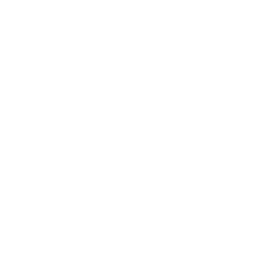
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Design-Adjusted Purchase Likelihood from a Mall-Intercept Survey</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Retail / Consumer Insights &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

A mall-intercept survey of 100 shoppers carries a complex sample design: respondents are **stratified** by mall location tier (Urban / Suburban / Rural) and **clustered** within interviewer groups, and each response carries a **survey weight**. Ignoring that design understates standard errors. We model the binary outcome **likely to buy** (47 of 100 respondents) with `PROC SURVEYLOGISTIC`, using `STRATA`, `CLUSTER`, and `WEIGHT` so the variance is estimated by Taylor-series linearization rather than as if the data were a simple random sample.

The design-adjusted model recovers two strongly significant levers. **Brand awareness** dominates: high-awareness shoppers have **9.4 times** the odds of being likely to buy versus low-awareness shoppers (95% CI 2.49-35.6, *p* = 0.003). **Promotion exposure** raises the odds **2.9-fold** (95% CI 1.56-5.27, *p* = 0.002). Prior-purchase history (OR 2.26) and price sensitivity (OR 0.90) point in the expected directions but are not significant at this sample size. The model separates likely from unlikely buyers well (*c* = 0.751).

## Data Sources

| Source | Description | Records |
|--------|-------------|--------|
| WORK.MALL_SURVEY | Mall-intercept consumer survey: purchase outcome, shopping context, and survey-design keys (stratum, cluster, weight) | 100 |

The environment runs in unlicensed mode, so the synthetic survey is sized to 100 respondents. The design keys are constructed so the sample spans **3 strata** (mall tiers) and **18 interviewer clusters** -- enough structure for the Taylor-series variance estimator to engage.

---

In [1]:
/* --------------------------------------------------------
   Generate a synthetic mall-intercept survey (100 obs).
   Binary outcome: likely_to_buy (1 = likely, 0 = not).
   Complex survey design: strata x cluster x weight.
   -------------------------------------------------------- */
data work.mall_survey;
    call streaminit(42);
    length mall_tier $8 product_category $11 age_group $5
           brand_awareness $6;
    array tier_list[3] $8 _temporary_ ('Urban' 'Suburban' 'Rural');
    array prod_list[3] $11 _temporary_
        ('Electronics' 'Apparel' 'Home Goods');
    array age_list[4] $5 _temporary_ ('18-24' '25-34' '35-54' '55+');
    array brand_list[3] $6 _temporary_ ('Low' 'Medium' 'High');

    do respondent_id = 1 to 100;
        /* Survey design: stratified by mall tier */
        tier_idx = int(rand('uniform') * 3) + 1;
        mall_tier = tier_list[tier_idx];
        stratum_mall = tier_idx;
        mall_id = tier_idx * 10 + int(rand('uniform') * 3) + 1;
        interviewer_group = mall_id * 10 + int(rand('uniform') * 2) + 1;
        cluster_intv = interviewer_group;
        survey_weight = round(rand('uniform') * 4 + 1, 0.01);

        /* Product category and respondent characteristics */
        prod_idx = int(rand('uniform') * 3) + 1;
        product_category = prod_list[prod_idx];
        age_idx = int(rand('uniform') * 4) + 1;
        age_group = age_list[age_idx];
        household_income_k = round(rand('exponential') * 50 + 25, 1);
        if household_income_k > 250 then household_income_k = 250;

        /* Shopping context and marketing exposure */
        time_in_store_min = int(rand('exponential') * 18 + 5);
        if time_in_store_min > 120 then time_in_store_min = 120;
        brand_idx = int(rand('uniform') * 3) + 1;
        brand_awareness = brand_list[brand_idx];
        saw_promotion = (rand('uniform') > 0.5);
        price_sensitivity = round(rand('normal', 5, 2), 0.1);
        if price_sensitivity < 1 then price_sensitivity = 1;
        if price_sensitivity > 10 then price_sensitivity = 10;
        prior_purchase = (rand('uniform') > 0.6);

        /* Outcome: probability of being likely to buy */
        linear_pred = -0.9
            - 0.22 * price_sensitivity
            + 0.55 * (brand_idx - 1)
            + 0.80 * saw_promotion
            + 0.65 * prior_purchase
            + 0.015 * time_in_store_min
            + 0.004 * household_income_k;
        prob_likely = 1 / (1 + exp(-linear_pred));
        likely_to_buy = (rand('uniform') < prob_likely);

        length intent_label $11;
        if likely_to_buy = 1 then intent_label = 'Likely';
        else intent_label = 'Not Likely';

        output;
    end;
    drop tier_idx prod_idx age_idx brand_idx
         linear_pred prob_likely;
run;

NOTE: DATA work.mall_survey


NOTE: Wrote work.mall_survey (100 rows, 18 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

                                    Weighted Purchase Likelihood by Product Category                                    

                                                   The FREQ Procedure

Table of product_category by intent_label

product_category |    Likely |Not Likely |      Total
-----------------+-----------+-----------+-----------
Apparel          |        64 |        64 |        128
-----------------+-----------+-----------+-----------
Electronics      |        32 |        60 |         93
-----------------+-----------+-----------+-----------
Home Goods       |        32 |        41 |         74
-----------------+-----------+-----------+-----------
Total            |       129 |       166 |        296



NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_product_category_intent_label.spec.json
NOTE: PROC FREQ statement used.


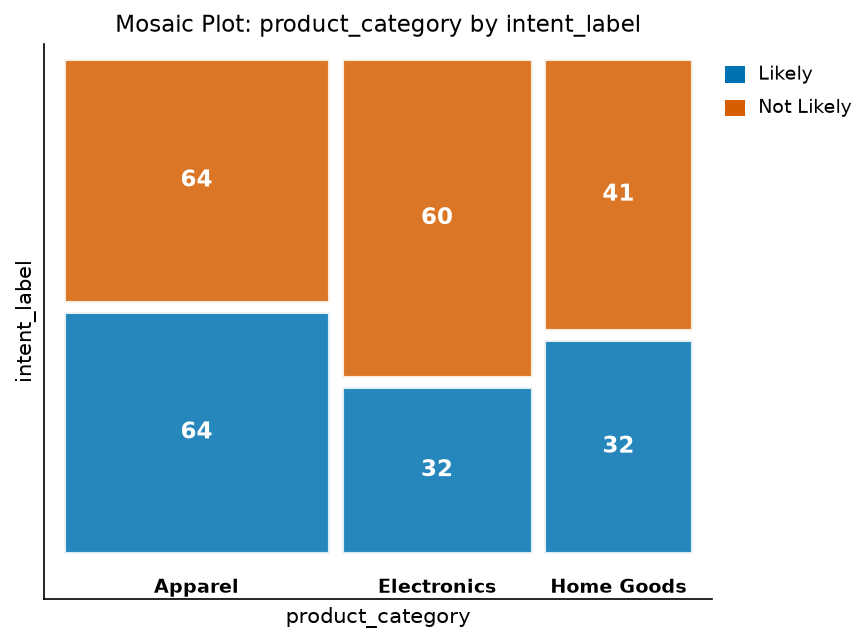

In [2]:
/* --------------------------------------------------------
   Baseline: purchase likelihood by product category,
   weighted by the survey weight.
   -------------------------------------------------------- */
proc freq data=work.mall_survey;
    tables product_category * intent_label / nocum nopercent;
    weight survey_weight;
    title 'Weighted Purchase Likelihood by Product Category';
run;

---

                                    Weighted Purchase Likelihood by Product Category                                    



NOTE: PROC SGPLOT data=work.mall_survey

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


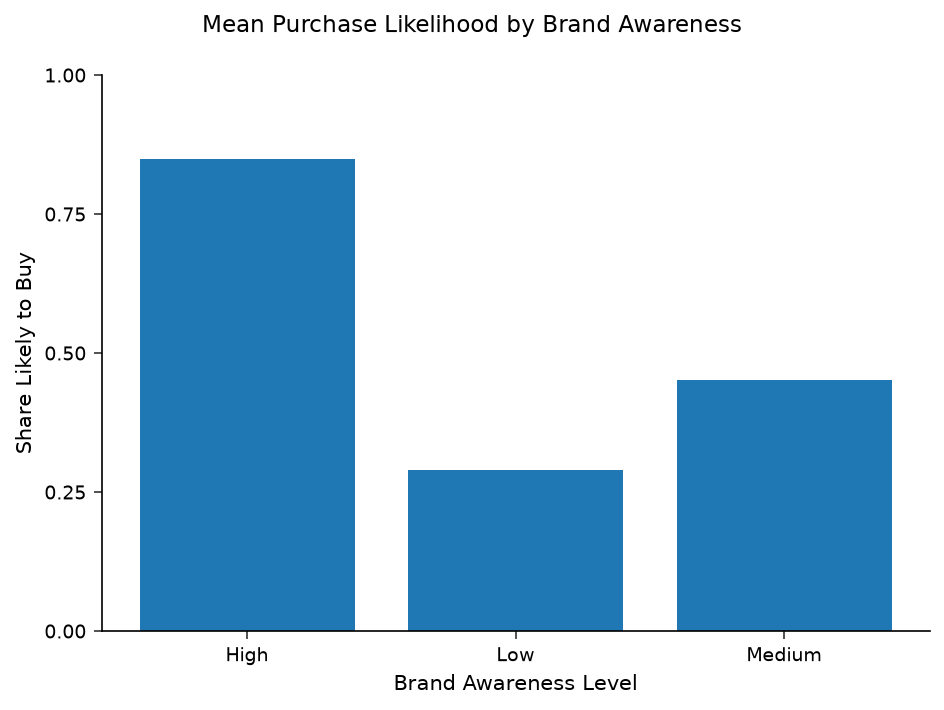

In [3]:
/* --------------------------------------------------------
   Mean purchase likelihood by brand awareness level.
   -------------------------------------------------------- */
proc sgplot data=work.mall_survey;
    vbar brand_awareness / response=likely_to_buy stat=mean;
    yaxis label='Share Likely to Buy' values=(0 to 1 by 0.25);
    xaxis label='Brand Awareness Level';
    title 'Mean Purchase Likelihood by Brand Awareness';
run;

---

In [4]:
/* --------------------------------------------------------
   PROC SURVEYLOGISTIC: design-adjusted logistic model
   for likely_to_buy. STRATA by mall tier, CLUSTER by
   interviewer group, WEIGHT by survey weight -> the
   standard errors use Taylor-series linearization.
   -------------------------------------------------------- */
proc surveylogistic data=work.mall_survey;
    strata stratum_mall;
    cluster cluster_intv;
    weight survey_weight;
    class brand_awareness (ref='Low') / param=ref;
    model likely_to_buy(event='1') =
        price_sensitivity brand_awareness saw_promotion
        prior_purchase time_in_store_min household_income_k
        / clb;
    oddsratio price_sensitivity;
    oddsratio brand_awareness;
    oddsratio saw_promotion;
    ods output ParameterEstimates=work.intent_params;
    title 'Design-Adjusted Purchase Likelihood (Mall-Intercept Survey)';
run;

                                    Weighted Purchase Likelihood by Product Category                                    


                      The SURVEYLOGISTIC Procedure

  Number of Strata                3
  Number of Clusters             18
  Number of Observations        100
  Number of Events               47
  Number of Non-Events           53
  Link Function               logit
  Variance Method            TAYLOR

                Model Fit Statistics

  -2 Log Likelihood        112.2819
  AIC                      128.2819
  SC                       149.1232

                  Analysis of Maximum Likelihood Estimates

Parameter                   Estimate       Std Error     t Value    Pr > |t|        Lower CL        Upper CL
------------------------------------------------------------------------------------------------------------
Intercept                  -1.432957        0.705572     -2.0309      0.0604       -2.936848        0.070935
price_sensitivity          -0.104730  

NOTE: PROC SURVEYLOGISTIC data=work.mall_survey

NOTE: Using Python statsmodels version 0.14.6
NOTE: PROC SURVEYLOGISTIC completed.


In [5]:
/* --------------------------------------------------------
   Design-adjusted parameter estimates captured via
   ODS OUTPUT (standard errors, t values, p values, CIs).
   -------------------------------------------------------- */
proc print data=work.intent_params noobs;
    title 'Design-Adjusted Parameter Estimates';
run;

                                          Design-Adjusted Parameter Estimates                                           

             PARAMETER       ESTIMATE        STDERR         TVALUE         PROBT        LOWERCL       UPPERCL
Intercept               -1.4329567076   0.705572091  -2.0309146661  0.0603781742  -2.9368480203  0.0709346051
PRICE_SENSITIVITY       -0.1047297591  0.1074463477  -0.9747167903  0.3451587913  -0.3337462281  0.1242867098
BRAND_AWARENESS_High     2.2430706288  0.6239769751   3.5947971133  0.0026538263   0.9130951888  3.5730460688
BRAND_AWARENESS_Medium   0.3812444003  0.4456731515   0.8554349728  0.4057675852   -0.568685436  1.3311742366
SAW_PROMOTION            1.0532618356  0.2860463165   3.6821373837  0.0022188082   0.4435685442   1.662955127
PRIOR_PURCHASE            0.816706551  0.5705846033   1.4313504891  0.1728348947  -0.3994657424  2.0328788444
TIME_IN_STORE_MIN        0.0128911592  0.0122861291   1.0492449782  0.3106775784   -0.013296105  0.039078423

NOTE: PROC PRINT data=work.intent_params

NOTE: PROC PRINT completed: 8 observations printed, 7 variables


---

### Interpretation

Because the model declares the survey design, the inference reported above is **design-adjusted**: `PROC SURVEYLOGISTIC` reports `Variance Method TAYLOR` across **3 strata** and **18 clusters**, and every standard error reflects the clustering of responses within interviewer groups rather than assuming independent observations.

**Brand awareness is the dominant lever.** High-awareness shoppers have **9.42 times** the odds of being likely to buy compared with low-awareness shoppers (95% CI 2.49-35.6, *p* = 0.003), while medium awareness shows only a modest, non-significant lift (OR 1.46). This tracks the raw weighted data, where the share likely to buy climbs from 0.29 at low awareness to 0.45 at medium and 0.85 at high.

**Promotion exposure matters.** Shoppers who saw a promotion have **2.87 times** the odds of being likely to buy (95% CI 1.56-5.27, *p* = 0.002) -- the second clearly significant driver. **Prior-purchase history** points the same way (OR 2.26) but does not reach significance here (*p* = 0.17), and **price sensitivity** trends as a deterrent (OR 0.90 per point, *p* = 0.35). Neither time in store nor household income contributes meaningfully at this sample size.

The fitted model discriminates likely from unlikely buyers reasonably well, with a *c* statistic of **0.751**. The clear, actionable takeaway for a retail-insights team: investments that lift brand awareness and well-targeted in-store promotions move purchase intent the most, and these conclusions hold once the survey's stratified, clustered design is properly accounted for.

---

In [6]:
/* --------------------------------------------------------
   Export the design-adjusted parameter estimates.
   -------------------------------------------------------- */
proc export data=work.intent_params
    outfile='purchase_likelihood_estimates.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.intent_params outfile=purchase_likelihood_estimates.csv

NOTE: Exported 8 rows to purchase_likelihood_estimates.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>